# Segundo notebook

## Importação dos dados referentes as voltas de qualificação para a corrida

In [103]:
import csv

def load_csv(path):
    with open(path, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        return list(reader)

qualifying = load_csv('../data/raw/qualifying.csv')
drivers = load_csv('../data/raw/drivers.csv')
races = load_csv('../data/raw/races.csv')

print(f"Qualificações: {len(qualifying)}")
print(qualifying[0])

Qualificações: 10494
{'qualifyId': '1', 'raceId': '18', 'driverId': '1', 'constructorId': '1', 'number': '22', 'position': '1', 'q1': '1:26.572', 'q2': '1:25.187', 'q3': '1:26.714'}


In [104]:
def tempo_para_ms(tempo):
    if tempo == '\\N' or tempo == '':
        return None
    partes = tempo.strip().split(':')
    minutos = int(partes[0])
    segundos = float(partes[1])
    return int((minutos * 60 + segundos) * 1000)

# Teste
print(tempo_para_ms('1:26.572'))  # deve retornar 86572

86572


## Coleta dos dados

In [105]:
dados_quali = []
for q in qualifying:
    q1 = tempo_para_ms(q['q1'])
    q3 = tempo_para_ms(q['q3'])
    pos = q['position']

    # ignorar quem não participou do Q3 (só top 10 vai ao Q3)
    if q3 is None or q1 is None:
        continue

    dados_quali.append({
        'q1': q1,
        'q3': q3,
        'target': 1 if pos == '1' else 0
    })

print(f"Total: {len(dados_quali)}")
print(f"Poles (1): {sum(d['target'] == 1 for d in dados_quali)}")
print(f"Não poles (0): {sum(d['target'] == 0 for d in dados_quali)}")

Total: 3629
Poles (1): 374
Não poles (0): 3255


## Balanceamento

In [106]:

classe_1 = [d for d in dados_quali if d['target'] == 1]
classe_0 = [d for d in dados_quali if d['target'] == 0]
import random
random.seed(42)
classe_0_bal = random.sample(classe_0, len(classe_1))
dados_bal = classe_1 + classe_0_bal
random.shuffle(dados_bal)






## Normalizar


In [107]:
q1_raw = [d['q1'] for d in dados_bal]
q3_raw = [d['q3'] for d in dados_bal]
targets = [d['target'] for d in dados_bal]

def normalizar(lista):
    minv = min(lista)
    maxv = max(lista)
    return [(x - minv) / (maxv - minv) for x in lista]

q1_norm = normalizar(q1_raw)
q3_norm = normalizar(q3_raw)

X = [[q1_norm[i], q3_norm[i]] for i in range(len(dados_bal))]
y = targets


## Treinar e avaliar

In [108]:
# Treino/teste
split = int(len(X) * 0.8)
X_treino, y_treino = X[:split], y[:split]
X_teste,  y_teste  = X[split:], y[split:]

def degrau(soma):
    return 1 if soma >= 0 else 0

# Treinamento
def treinar_perceptron(X, y, taxa=0.1, epocas=100):
    w = [0.0, 0.0]  # pesos para ms e lap
    b = 0.0          # bias
    historico_erro = []

    for epoca in range(epocas):
        total_erro = 0
        for i in range(len(X)):
            soma = w[0]*X[i][0] + w[1]*X[i][1] + b
            pred = degrau(soma)
            erro = y[i] - pred
            w[0] += taxa * erro * X[i][0]
            w[1] += taxa * erro * X[i][1]
            b    += taxa * erro
            total_erro += abs(erro)
        
        historico_erro.append(total_erro)
        if epoca % 10 == 0:
            print(f"Época {epoca} - Erros: {total_erro}")

    return w, b, historico_erro


def avaliar(X, y, w, b):
    acertos = 0
    for i in range(len(X)):
        soma = w[0]*X[i][0] + w[1]*X[i][1] + b
        pred = degrau(soma)
        if pred == y[i]:
            acertos += 1
    return acertos / len(y)


w, b, historico = treinar_perceptron(X_treino, y_treino)
acuracia = avaliar(X_teste, y_teste, w, b)
print(f"\nAcurácia: {acuracia:.2%}")

Época 0 - Erros: 287
Época 10 - Erros: 288
Época 20 - Erros: 286
Época 30 - Erros: 288
Época 40 - Erros: 282
Época 50 - Erros: 288
Época 60 - Erros: 288
Época 70 - Erros: 288
Época 80 - Erros: 286
Época 90 - Erros: 288

Acurácia: 57.33%


### O resultado de 57% continua insatisfátorio, então a abordagem será alterada para uma análise de melhoria entre os tempos:

In [109]:
dados_quali2 = []
for q in qualifying:
    q1 = tempo_para_ms(q['q1'])
    q3 = tempo_para_ms(q['q3'])
    pos = q['position']

    if q3 is None or q1 is None:
        continue

    diferenca = q1 - q3  # positivo = melhorou, negativo = piorou

    dados_quali2.append({
        'q3': q3,
        'diferenca': diferenca,
        'target': 1 if pos == '1' else 0
    })

## Balancear

In [110]:

classe_1 = [d for d in dados_quali2 if d['target'] == 1]
classe_0 = [d for d in dados_quali2 if d['target'] == 0]
random.seed(42)
classe_0_bal = random.sample(classe_0, len(classe_1))
dados_bal2 = classe_1 + classe_0_bal
random.shuffle(dados_bal2)


## Normalizar

In [111]:

q3_raw = [d['q3'] for d in dados_bal2]
diferenca_raw = [d['diferenca'] for d in dados_bal2]
targets = [d['target'] for d in dados_bal2]

q3_norm = normalizar(q3_raw)
diferenca_norm = normalizar(diferenca_raw)

X = [[diferenca_norm[i], q3_norm[i]] for i in range(len(dados_bal2))]
y = targets

# Treino/teste
split = int(len(X) * 0.8)
X_treino, y_treino = X[:split], y[:split]
X_teste,  y_teste  = X[split:], y[split:]

## Treinar e avaliar

In [112]:

w, b, historico = treinar_perceptron(X_treino, y_treino)
acuracia = avaliar(X_teste, y_teste, w, b)
print(f"\nAcurácia: {acuracia:.2%}")

Época 0 - Erros: 292
Época 10 - Erros: 278
Época 20 - Erros: 279
Época 30 - Erros: 277
Época 40 - Erros: 280
Época 50 - Erros: 281
Época 60 - Erros: 281
Época 70 - Erros: 281
Época 80 - Erros: 282
Época 90 - Erros: 283

Acurácia: 57.33%


### Pouca diferença. Como a Formula 1 usa um sistema de eliminação para a qualificação, é esperado que o piloto que passou para o Q3 tenha melhorado em relação ao seu tempo do Q1

# Nova abordagem:

### Calculo de tempos relativos para cada corrida

In [113]:
# Calcular o menor Q3 por corrida
melhor_q3_por_corrida = {}
for q in qualifying:
    q3 = tempo_para_ms(q['q3'])
    rid = q['raceId']
    if q3 is None:
        continue
    if rid not in melhor_q3_por_corrida:
        melhor_q3_por_corrida[rid] = q3
    else:
        melhor_q3_por_corrida[rid] = min(melhor_q3_por_corrida[rid], q3)

# split guardando o driverId
dados_com_id = []
for q in qualifying:
    q1 = tempo_para_ms(q['q1'])
    q3 = tempo_para_ms(q['q3'])
    rid = q['raceId']
    pos = q['position']

    if q3 is None or q1 is None:
        continue

    melhor = melhor_q3_por_corrida[rid]
    q3_relativo = q3 / melhor

    dados_com_id.append({
        'q3_relativo': q3_relativo,
        'diferenca': q1 - q3,
        'target': 1 if pos == '1' else 0,
        'driverId': q['driverId'],
        'raceId': rid
    })




## Balancear mantendo o id

In [114]:

classe_1 = [d for d in dados_com_id if d['target'] == 1]
classe_0 = [d for d in dados_com_id if d['target'] == 0]
random.seed(42)
classe_0_bal = random.sample(classe_0, len(classe_1))
dados_bal = classe_1 + classe_0_bal
random.shuffle(dados_bal)


## Normalizar

In [115]:
q3_raw = [d['q3_relativo'] for d in dados_bal]
dif_raw = [d['diferenca'] for d in dados_bal]
targets = [d['target'] for d in dados_bal]

q3_norm = normalizar(q3_raw)
dif_norm = normalizar(dif_raw)

X = [[q3_norm[i], dif_norm[i]] for i in range(len(dados_bal))]
y = targets

## Split

In [116]:
split = int(len(X) * 0.8)
X_treino, y_treino = X[:split], y[:split]
X_teste,  y_teste  = X[split:], y[split:]
dados_teste = dados_bal[split:]  # guarda os metadados do teste

## Treinar e avaliar

In [117]:

w, b, historico = treinar_perceptron(X_treino, y_treino)
acuracia = avaliar(X_teste, y_teste, w, b)
print(f"Acurácia: {acuracia:.2%}")

Época 0 - Erros: 264
Época 10 - Erros: 130
Época 20 - Erros: 94
Época 30 - Erros: 74
Época 40 - Erros: 68
Época 50 - Erros: 68
Época 60 - Erros: 68
Época 70 - Erros: 62
Época 80 - Erros: 58
Época 90 - Erros: 54
Acurácia: 94.67%


# Resultado: Desempenho muito superior

# Análise gráfica do modelo:

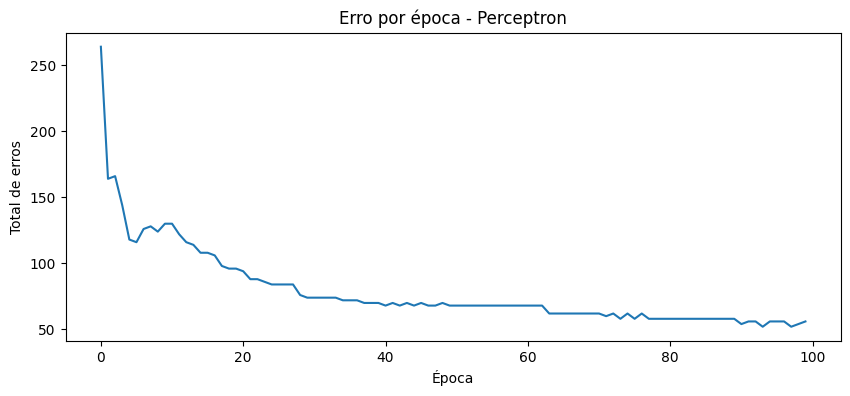

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(historico)
plt.title('Erro por época - Perceptron')
plt.xlabel('Época')
plt.ylabel('Total de erros')
plt.show()

# Exemplos

In [119]:
race_map = {r['raceId']: r['name'] for r in races}
driver_map = {d['driverId']: d['surname'] for d in drivers}

print("Exemplos de predição\n")
for i in range(10):
    amostra = X_teste[i]
    real = y_teste[i]
    soma = w[0]*amostra[0] + w[1]*amostra[1] + b
    pred = degrau(soma)
    nome = driver_map.get(dados_teste[i]['driverId'], '?')
    corrida = race_map.get(dados_teste[i]['raceId'], '?')
    print(f"{nome} | {corrida}")
    print(f"Real: {'POLE' if real == 1 else 'NÃO POLE'} | Previsto: {'POLE' if pred == 1 else 'NÃO POLE'} | {'✅' if real == pred else '❌'}\n")

Exemplos de predição

Gasly | Miami Grand Prix
Real: NÃO POLE | Previsto: NÃO POLE | ✅

Webber | Chinese Grand Prix
Real: NÃO POLE | Previsto: NÃO POLE | ✅

Glock | Bahrain Grand Prix
Real: NÃO POLE | Previsto: NÃO POLE | ✅

Pérez | Belgian Grand Prix
Real: NÃO POLE | Previsto: NÃO POLE | ✅

Webber | Australian Grand Prix
Real: NÃO POLE | Previsto: NÃO POLE | ✅

Rosberg | Italian Grand Prix
Real: NÃO POLE | Previsto: NÃO POLE | ✅

Verstappen | Japanese Grand Prix
Real: POLE | Previsto: POLE | ✅

Hamilton | Spanish Grand Prix
Real: NÃO POLE | Previsto: NÃO POLE | ✅

Hamilton | Spanish Grand Prix
Real: POLE | Previsto: POLE | ✅

Räikkönen | Monaco Grand Prix
Real: NÃO POLE | Previsto: NÃO POLE | ✅

